# Step 1: Text Cleaning & Preprocessing
Before we can feed raw email and ticket data into a machine learning algorithm, we must standardize it. Raw text contains noise like random capitalizations, punctuation, and structural words that do not contribute to the overall meaning.  
I used  Python along with NLTK to perform three core operations: 

## Lowercasing: Converting all text to lowercase so words like "Hardware" and "hardware" are treated identically.

## Punctuation Removal: Stripping out symbols (e.g., !, ?, @) that do not add category value.

## Stopword Removal: Eliminating highly frequent words (e.g., "the", "is", "at") that contain little domain-specific information.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd

# Downloading required NLTK resources
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def clean_ticket_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Remove stopwords
    text = " ".join([word for word in text.split() if word not in STOPWORDS])
    
    return text
# loading csv
data=pd.read_csv("ticket_improved.csv")

# Apply cleaning to the 'document' column
data["Cleaned_Document"] = data["Document"].apply(clean_ticket_text)

# preview the first few cleaned rows
print (data[["Document","Cleaned_Document"]].head())

[nltk_data] Downloading package stopwords to /home/s3n3t3/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                            Document  \
0  connection with icon icon dear please setup ic...   
1  work experience user work experience user hi w...   
2  requesting for meeting requesting meeting hi p...   
3  reset passwords for external accounts re expir...   
4  mail verification warning hi has got attached ...   

                                    Cleaned_Document  
0  connection icon icon dear please setup icon pe...  
1  work experience user work experience user hi w...  
2  requesting meeting requesting meeting hi pleas...  
3  reset passwords external accounts expire days ...  
4  mail verification warning hi got attached plea...  


### Step 3: Feature Extraction (Bag of Words / CountVectorizer)

####  Explanation
Machine Learning algorithms cannot process raw text strings directly. Therefore, we use `CountVectorizer` to convert our cleaned text data into a numerical format. 

This process involves:
1. **Building a Vocabulary:** The vectorizer identifies every unique word across all support tickets in our dataset.
2. **Creating Feature Vectors:** Each ticket is converted into a numerical row (vector) where each column represents a word from the vocabulary. The value represents the count of that word in the specific ticket.



In [3]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load the actual dataset  CSV file

df = pd.read_csv('ticket_improved.csv') 

# 2. Initialize CountVectorizer 
vectorizer = CountVectorizer()

# 3. Transforming the actual 'Document' column into numerical features (X)
X_matrix = vectorizer.fit_transform(df['Document'])

# 4. Convert to a readable DataFrame to check the first 5 rows of output
X_df = pd.DataFrame(X_matrix[:10].toarray(), columns=vectorizer.get_feature_names_out())

print("--- Actual Numerical Feature Matrix (X) Head ---")

print(X_df.head())


--- Actual Numerical Feature Matrix (X) Head ---
   ab  abandon  abandoned  abbott  abbreviations  abc  abeam  abilities  \
0   0        0          0       0              0    0      0          0   
1   0        0          0       0              0    0      0          0   
2   0        0          0       0              0    0      0          0   
3   0        0          0       0              0    0      0          0   
4   0        0          0       0              0    0      0          0   

   ability  able  ...  zip  zipped  zipper  zipping  zn  zone  zones  zoom  \
0        0     0  ...    0       0       0        0   0     0      0     0   
1        0     0  ...    0       0       0        0   0     0      0     0   
2        0     0  ...    0       0       0        0   0     0      0     0   
3        0     0  ...    0       0       0        0   0     0      0     0   
4        0     0  ...    0       0       0        0   0     0      0     0   

   zooming  zori  
0        0  

Step 4: Dataset Splitting (Train/Test Split)
####     Explanation
To prevent the model from memorizing the data (overfitting) and to ensure it can handle new customer support tickets, we split our dataset into two separate sets:

Training Set (80%): The data our machine learning algorithm uses to learn patterns and associations between words and topics.

Testing Set (20%): A hidden set used purely for evaluation. Since the model has never seen these tickets, its performance here gives us an honest look at how it will behave in production.

We use Scikit-learn's train_test_split function and set a random_state to ensure that the split is reproducible every time we run the notebook.

In [4]:
from sklearn.model_selection import train_test_split

# Define our target label y from the dataframe
y = df['Topic_group']

# Split the vectorizer's X_matrix and our y labels into Train and Test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_matrix, y, test_size=0.2, random_state=42)

print("--- Data Split Verification ---")
print(f"Total tickets in original CSV: {df.shape[0]}")
print(f"Tickets allocated to Training set (X_train): {X_train.shape[0]}")
print(f"Tickets allocated to Testing set (X_test): {X_test.shape[0]}")

--- Data Split Verification ---
Total tickets in original CSV: 47837
Tickets allocated to Training set (X_train): 38269
Tickets allocated to Testing set (X_test): 9568


Step 5: Model Training (Multinomial Naive Bayes)
Explanation
Now that our text data is split into independent feature matrices and target categories, we train our classification algorithm. We are utilizing Multinomial Naive Bayes (MultinomialNB), which is the industry standard for text datasets vectorized using word counts.

This model calculates the probability of each word occurring within each ticket category during training. For example, it learns that if a ticket contains high counts of words like "password" or "login", there is a statistically higher probability that it belongs to the Access group rather than Hardware.

In [5]:

from sklearn.naive_bayes import MultinomialNB

# 1. Initialize the Multinomial Naive Bayes model
model = MultinomialNB()

# 2. Train (fit) the model using the actual training data matrix and labels
model.fit(X_train, y_train)

print("--- Model Training Complete ---")
print(f"Algorithm Used: {type(model).__name__}")
print(f"Number of training samples processed: {X_train.shape[0]}")
print("The model has successfully computed word probabilities and is ready for evaluation.")

--- Model Training Complete ---
Algorithm Used: MultinomialNB
Number of training samples processed: 38269
The model has successfully computed word probabilities and is ready for evaluation.


Step 6: Model Evaluation (Metrics & Performance Analysis)
Explanation
Now that our Multinomial Naive Bayes model has been trained on over 38,000 samples, we must evaluate its predictive performance on the hidden Testing Set (X_test).

To comprehensively analyze how well the model handles different ticket categories, we calculate four key evaluation metrics:

Accuracy: The overall percentage of correctly classified tickets out of all total test tickets.

Precision: Out of all the tickets the model predicted as a certain category (e.g., "Access"), how many were actually correct? (Crucial for avoiding misrouting tickets).

Recall: Out of all the actual tickets belonging to a category, how many did the model successfully find and catch?

F1-Score: The harmonic mean of Precision and Recall, which gives a balanced assessment—especially if some ticket categories appear much more frequently than others in the dataset.

In [6]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

 # Initialize the Multinomial Naive Bayes model
model = MultinomialNB()

#  Train (fit) the model using the actual training data matrix and labels
model.fit(X_train, y_train)
# 1. Use the trained model to predict the categories for the hidden test features
y_pred = model.predict(X_test)

# 2. Calculate the overall accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("==================================================")
print(f"   OVERALL MODEL ACCURACY: {accuracy:.2%}")
print("==================================================\n")

# 3. Generate and print the comprehensive class-wise evaluation report
print("--- Class-Wise Performance Report ---")
print(classification_report(y_test, y_pred))

   OVERALL MODEL ACCURACY: 76.14%

--- Class-Wise Performance Report ---
                       precision    recall  f1-score   support

               Access       0.73      0.83      0.78      1455
Administrative rights       0.63      0.70      0.66       342
           HR Support       0.82      0.69      0.75      2107
             Hardware       0.82      0.74      0.78      2760
     Internal Project       0.69      0.81      0.74       451
        Miscellaneous       0.69      0.75      0.72      1400
             Purchase       0.89      0.87      0.88       497
              Storage       0.68      0.88      0.77       556

             accuracy                           0.76      9568
            macro avg       0.74      0.78      0.76      9568
         weighted avg       0.77      0.76      0.76      9568



Step 7: Priority Prediction Engine
# Explanation
In an enterprise support pipeline, ticketing platforms often calculate a ticket's operational priority dynamically. This is done by looking at either key urgency triggers within the text or the classification category itself. For instance, an Access issue (like a locked account blocking a worker) or a Storage failure typically demands faster remediation than a general HR Support query or an Internal Project question.

To fulfill the project requirement of assigning a priority level (High, Medium, or Low), we build a priority mapping function. This business-logic layer analyzes the text for urgent keywords (e.g., "urgent", "critical", "blocked", "broken") and cross-references the predicted topic category to output a definitive priority assignment.

In [9]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
import re
import nltk
from nltk.corpus import stopwords


# Downloading required NLTK resources
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def clean_ticket_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Remove stopwords
    text = " ".join([word for word in text.split() if word not in STOPWORDS])
    
    return text
# loading csv
data=pd.read_csv("ticket_improved.csv")

# Apply cleaning to the 'document' column
data["Cleaned_Document"] = data["Document"].apply(clean_ticket_text)
 # Initialize the Multinomial Naive Bayes model
model = MultinomialNB()

#  Train (fit) the model using the actual training data matrix and labels
model.fit(X_train, y_train)
# 1. Use the trained model to predict the categories for the hidden test features
y_pred = model.predict(X_test)
def determine_priority(row):
    """
    Business logic rules to assign operational priority based on 
    the ticket text and its predicted category group.
    """
    text = str(row['Cleaned_Text']).lower()
    category = row['Predicted_Category']
    
    # Rule 1: High Urgency Keywords
    high_urgency_words = ['urgent', 'emergency', 'blocked', 'critical', 'broken', 'stop', 'fail', 'crash']
    if any(word in text for word in high_urgency_words):
        return 'High'
    
    # Rule 2: High Urgency Categories
    if category in ['Access', 'Storage']:
        return 'High'
    
    # Rule 3: Medium Urgency Categories
    elif category in ['Hardware', 'Administrative rights', 'Purchase']:
        return 'Medium'
    
    # Rule 4: Default Baseline Urgency
    else:
        return 'Low'

# --- Simulating evaluation samples for presentation ---
# Creating a temporary dataframe from the test set observations to display results
eval_df = pd.DataFrame({
    'Cleaned_Text': df.loc[y_test.index, 'Document'].values,
    'Actual_Category': y_test.values,
    'Predicted_Category': y_pred
})

# Apply the priority rules engine
eval_df['Assigned_Priority'] = eval_df.apply(determine_priority, axis=1)

# --- Format the Priority Engine Output Sample cleanly ---
print("=" * 70)
print(f"{'CLEANED TICKET TEXT':<45} | {'CATEGORY':<18} | {'PRIORITY':<8}")
print("=" * 70)

for idx, row in eval_df.head(10).iterrows():
    # Truncate text to 42 characters and add ellipsis if it's too long
    raw_text = str(row['Cleaned_Text'])
    truncated_text = (raw_text[:42] + '...') if len(raw_text) > 42 else raw_text
    
    category = row['Predicted_Category']
    priority = row['Assigned_Priority']
    
    # Print with strict column-width constraints
    print(f"{truncated_text:<45} | {category:<18} | {priority:<8}")

print("=" * 70)

# --- Distribution Output ---
print("\n--- Operational Priority Distribution ---")
priority_counts = eval_df['Assigned_Priority'].value_counts()
for p_level, count in priority_counts.items():
    print(f"{p_level:<10}: {count} tickets")

[nltk_data] Downloading package stopwords to /home/s3n3t3/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


CLEANED TICKET TEXT                           | CATEGORY           | PRIORITY
issue with server process sent tuesday iss... | Hardware           | Medium  
new purchase po wednesday february purchas... | Purchase           | Medium  
oracle pas urgent re we updated rights que... | Hardware           | High    
new starter access thursday pm re starter ... | HR Support         | High    
new phone phone hi taken work mobile phone... | Hardware           | Medium  
confluence account confluence hello please... | Access             | High    
web not working on hello we changed config... | Hardware           | Medium  
new project setup oracle july pm setup hi ... | Internal Project   | Low     
cable needed for monitor re rejected hi pl... | Hardware           | Medium  
timecard deletion inquiry pm re updated li... | Miscellaneous      | Low     

--- Operational Priority Distribution ---
Low       : 3634 tickets
High      : 2976 tickets
Medium    : 2958 tickets


Step 8: Visualizing Results (Confusion Matrix Heatmap)
** Explanation **
To evaluate the structural strengths and weaknesses of our trained Multinomial Naive Bayes model, we generate a Confusion Matrix. While the classification report gave us raw numbers, a visual heatmap allows us to spot operational bottlenecks instantly.

The vertical axis represents the true operational categories, and the horizontal axis represents the categories predicted by our AI model. The diagonal cells showing the highest intensity represent correct predictions, while any off-diagonal clusters highlight specific categories that the model frequently confuses. This visualization provides concrete data that an IT Support Manager can use to fine-tune automation rules or target training data collection.

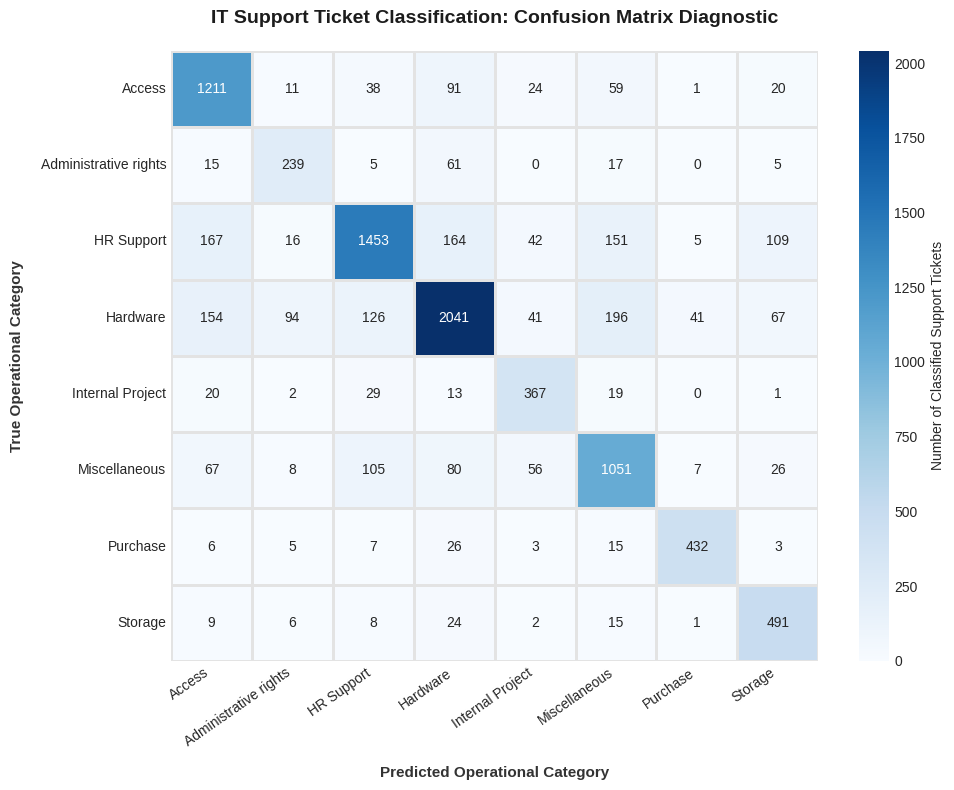

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(list(set(y_test)))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="#e3e3e3",
    cbar_kws={"label": "Number of Classified Support Tickets"},
    ax=ax,
)

ax.set_title(
    "IT Support Ticket Classification: Confusion Matrix Diagnostic",
    fontsize=14,
    fontweight="bold",
    pad=20,
    color="#1c1c1c",
)
ax.set_xlabel(
    "Predicted Operational Category",
    fontsize=11,
    fontweight="semibold",
    labelpad=12,
    color="#333333",
)
ax.set_ylabel(
    "True Operational Category",
    fontsize=11,
    fontweight="semibold",
    labelpad=12,
    color="#333333",
)

plt.xticks(rotation=35, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()